In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
import csv

movies = []

with open("C:\\Users\\HP\\Desktop\\Data Mining\\Movies.csv.csv", newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        movies.append(row)

print(movies[0]['rating'])

TV-MA


In [4]:
ratings = {
    "": 0,
    "G": 0,
    "TV-G": 0,
    "TV-Y": 0,
    "TV-Y7": 7,
    "TV-Y7-FV": 7,
    "PG": 10,
    "TV-PG": 10,
    "PG-13": 13,
    "TV-14": 14,
    "R": 17,
    "NC-17": 18,
    "TV-MA": 17,
    "NR": 0,
    "UR": 0,
}


In [5]:
mov_rating = [ratings[movie['rating']] for movie in movies]

1.  Compute mean, standard deviation, min, and max of the Rating field.

In [6]:
values = np.array(mov_rating)

mean_val = np.mean(values)
std_val = np.std(values)
min_val = np.min(values)
max_val = np.max(values)

print("Mean:", mean_val)
print("Standard Deviation:", std_val)
print("Min:", min_val)
print("Max:", max_val)

Mean: 13.42635161166046
Standard Deviation: 4.799946928472595
Min: 0
Max: 18


2. Plot a histogram of the Rating field using Matplotlib.

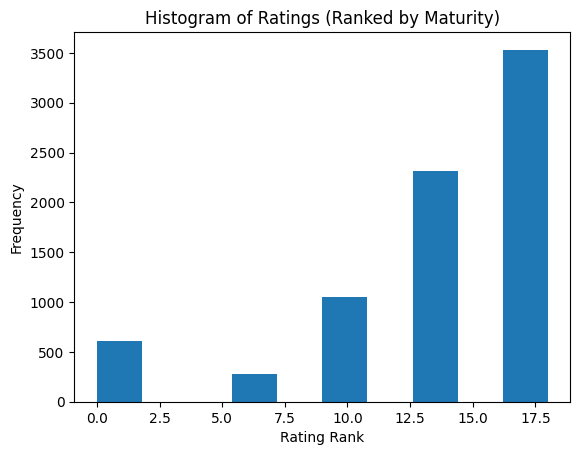

In [7]:
values = mov_rating

plt.hist(values)
plt.xlabel("Rating Rank")
plt.ylabel("Frequency")

plt.title("Histogram of Ratings (Ranked by Maturity)")
plt.show()

3. Find the mean rating grouped by Country and plot them as a bar chart.

In [8]:
country_ratings = {}

for movie in movies:
    country_field = movie['country']
    rating = movie['rating']

    if rating in ratings and country_field:
        rank = ratings[rating]

        # Split multiple countries
        countries = [c.strip() for c in country_field.split(',')]

        for country in countries:
            if country not in country_ratings:
                country_ratings[country] = []
            country_ratings[country].append(rank)

In [9]:
country_mean = {country: np.mean(values)
                for country, values in country_ratings.items()}

countries = list(country_mean.keys())
means = list(country_mean.values())

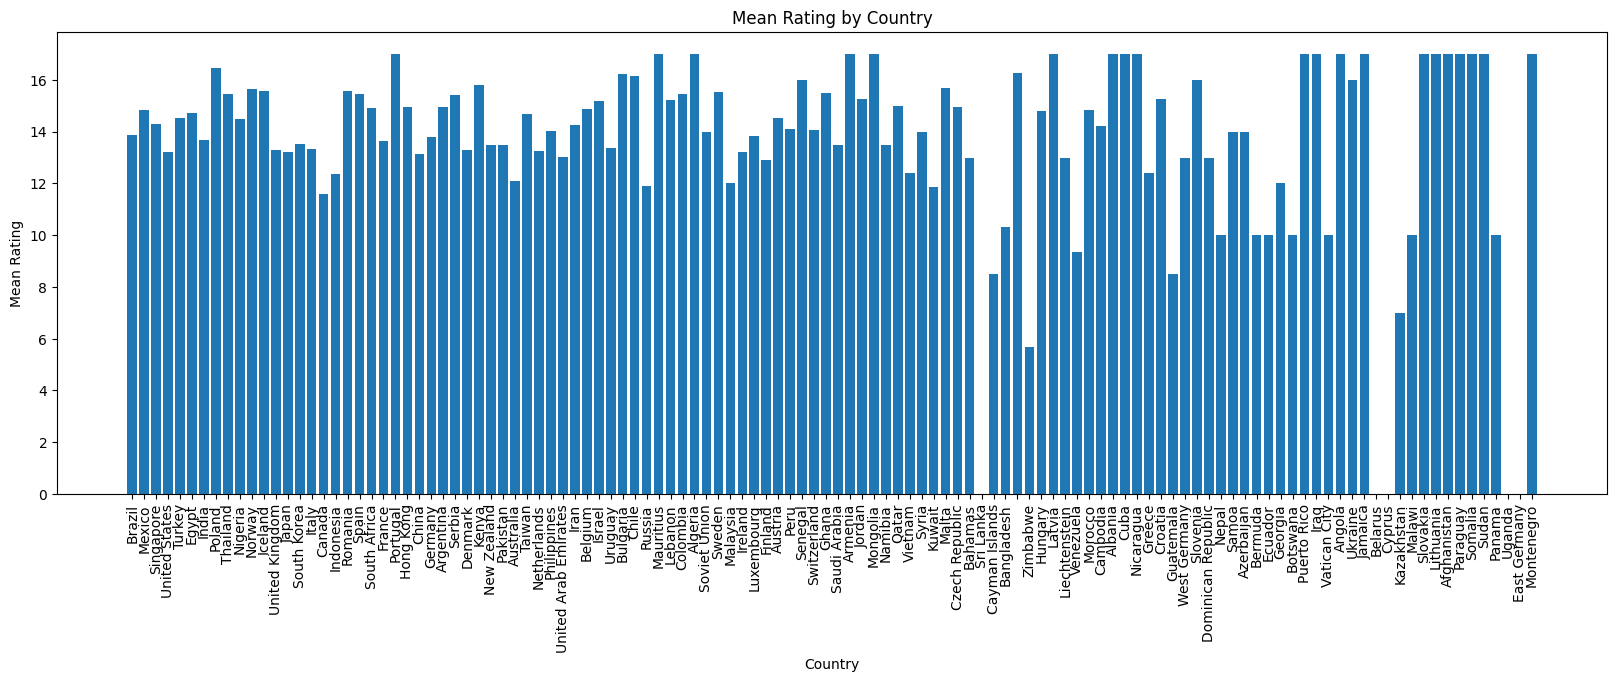

In [10]:
plt.figure(figsize=(20,6))
plt.bar(countries, means)
plt.xticks(rotation=90)
plt.xlabel("Country")
plt.ylabel("Mean Rating")
plt.title("Mean Rating by Country")
plt.show()

4. Find the minimum and maximum duration grouped by Year.

In [11]:
duration_ByYear = {}

for i in range(len(movies)):
    year = movies[i]["release_year"]
    duration_value = str(movies[i]["duration"])

    if "Season" in duration_value:
        duration_minutes = int(duration_value.split()[0]) * 300
    elif "min" in duration_value:
        duration_minutes = int(duration_value.split()[0])
    else:
        continue

    if year not in duration_ByYear:
        duration_ByYear[year] = {
            "min": duration_minutes,
            "max": duration_minutes
        }
    else:
        if duration_minutes < duration_ByYear[year]["min"]:
            duration_ByYear[year]["min"] = duration_minutes
        if duration_minutes > duration_ByYear[year]["max"]:
            duration_ByYear[year]["max"] = duration_minutes

print("Minimum and Maximum Duration by Year:\n")
for year in sorted(duration_ByYear):
    print(year, duration_ByYear[year])


Minimum and Maximum Duration by Year:

1925 {'min': 300, 'max': 300}
1942 {'min': 18, 'max': 52}
1943 {'min': 45, 'max': 82}
1944 {'min': 40, 'max': 76}
1945 {'min': 32, 'max': 63}
1946 {'min': 58, 'max': 300}
1947 {'min': 42, 'max': 42}
1954 {'min': 116, 'max': 120}
1955 {'min': 93, 'max': 111}
1956 {'min': 98, 'max': 104}
1958 {'min': 73, 'max': 115}
1959 {'min': 143, 'max': 143}
1960 {'min': 108, 'max': 181}
1962 {'min': 153, 'max': 185}
1963 {'min': 194, 'max': 1200}
1964 {'min': 228, 'max': 228}
1965 {'min': 103, 'max': 200}
1966 {'min': 116, 'max': 116}
1967 {'min': 90, 'max': 2400}
1968 {'min': 66, 'max': 900}
1969 {'min': 128, 'max': 152}
1970 {'min': 66, 'max': 130}
1971 {'min': 100, 'max': 181}
1972 {'min': 91, 'max': 300}
1973 {'min': 81, 'max': 253}
1974 {'min': 83, 'max': 1200}
1975 {'min': 92, 'max': 134}
1976 {'min': 98, 'max': 157}
1977 {'min': 84, 'max': 3000}
1978 {'min': 25, 'max': 141}
1979 {'min': 74, 'max': 300}
1980 {'min': 93, 'max': 161}
1981 {'min': 85, 'max':

5. Calculate average duration of movies yearwise , then plot them using both Matplotlib and Seaborn.

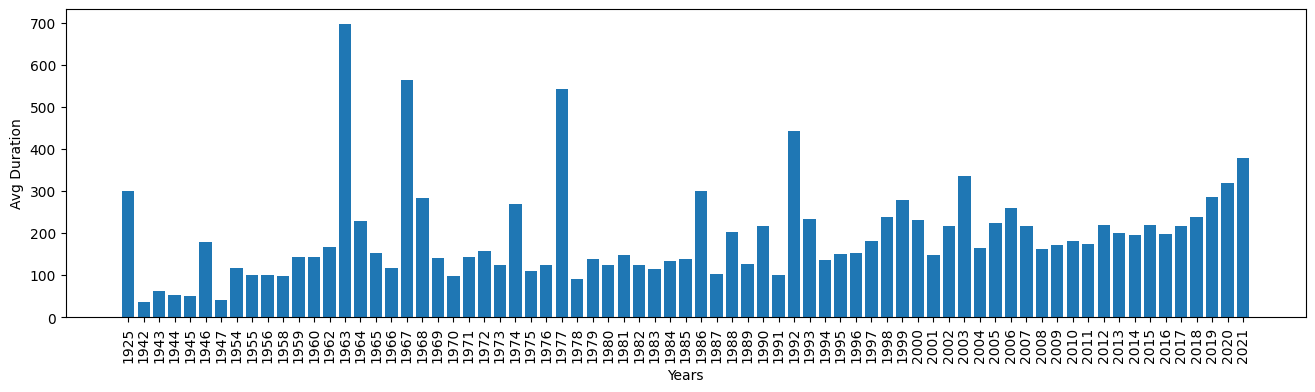

In [12]:
year_sum_count = {}

for i in range(len(movies)):
    year = movies[i]["release_year"]
    duration_value = str(movies[i]["duration"])

    if "Season" in duration_value:
        duration_minutes = int(duration_value.split()[0]) * 300
    elif "min" in duration_value:
        duration_minutes = int(duration_value.split()[0])
    else:
        continue

    if year not in year_sum_count:
        year_sum_count[year] = {
            "sum": duration_minutes,
            "count": 1
        }
    else:
        year_sum_count[year]["sum"] += duration_minutes
        year_sum_count[year]["count"] += 1

year_avg_dur = {}

for year in year_sum_count:
    total = year_sum_count[year]["sum"]
    count = year_sum_count[year]["count"]
    year_avg_dur[year] = total / count


x = sorted(year_avg_dur.keys())
y = [year_avg_dur[year] for year in x]

plt.figure(figsize=(16, 4))
plt.bar(x, y)
plt.xticks(rotation=90)
plt.xlabel("Years")
plt.ylabel("Avg Duration")
plt.show()



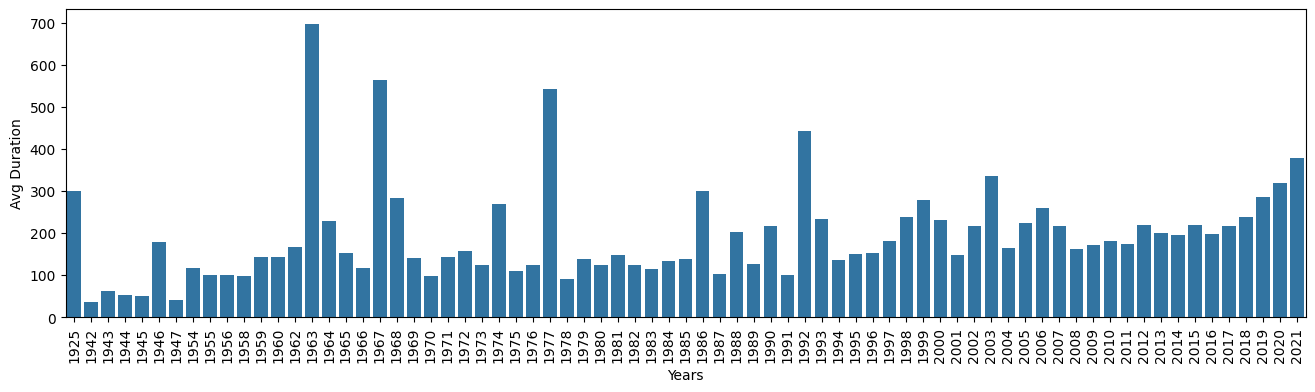

In [13]:
plt.figure(figsize=(16, 4))
sns.barplot(x=x, y=y)
plt.xticks(rotation=90)
plt.xlabel("Years")
plt.ylabel("Avg Duration")
plt.show()


6. Generate box plots for Rating, duration, and ReleaseYear.

In [14]:
def dur_to_num(d):
    if not d:
        return None
    
    d = d.strip()
    
    if "Season" in d:
        return int(d.split()[0]) * 300
    elif "min" in d:
        return int(d.split()[0])
    
    return None


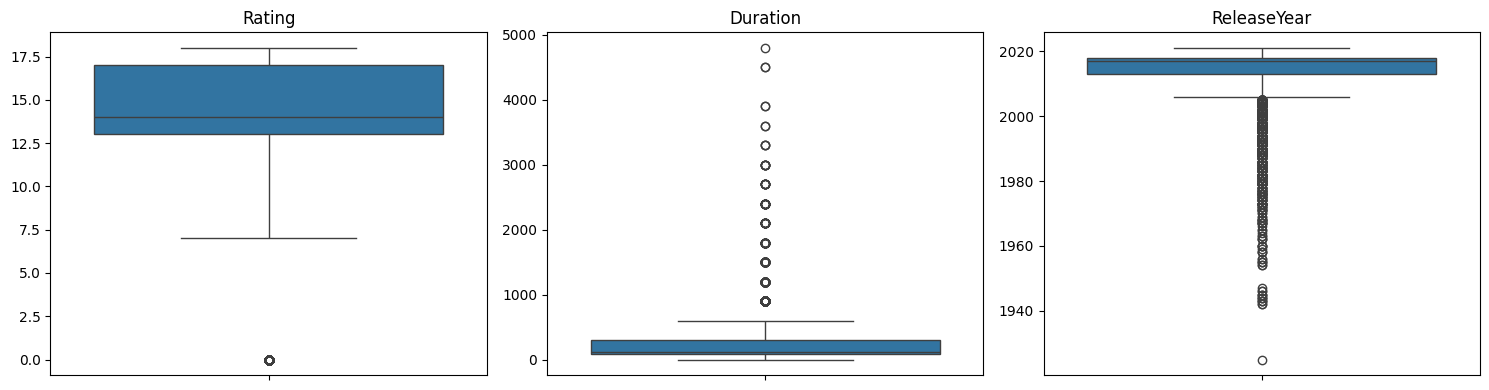

In [15]:
all_duration = []
all_rating = []
all_years = []

for movie in movies:
    duration = dur_to_num(movie['duration'])
    rating = movie['rating']
    year = movie['release_year']

    if duration and rating in ratings and year:
        all_duration.append(duration)
        all_rating.append(ratings[rating])
        all_years.append(int(year))


plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=all_rating)
plt.title("Rating")

plt.subplot(1, 3, 2)
sns.boxplot(y=all_duration)
plt.title("Duration")

plt.subplot(1, 3, 3)
sns.boxplot(y=all_years)
plt.title("ReleaseYear")

plt.tight_layout()
plt.show()


7. Use Seaborn’s factorplot (or catplot) to analyze how Rating varies across Genre and Country.

In [16]:
data = {}

for movie in movies:
        rating = movie['rating']
        countries = movie['country']
        genres = movie['listed_in']

        if rating in ratings and countries and genres:
            rating_num = ratings[rating]

            country_list = [c.strip() for c in countries.split(',')]
            genre_list = [g.strip() for g in genres.split(',')]

            for country in country_list:
                for genre in genre_list:
                    key = (genre, country)
                    if key not in data:
                        data[key] = []
                    data[key].append(rating_num)

# rating per (genre, country)
genres_plot = []
countries_plot = []
rating_plot = []

for (genre, country), values in data.items():
    for i in range(len(values)):
         
        genres_plot.append(genre)
        countries_plot.append(country)
        rating_plot.append(values[i])


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:123: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self._figure.tight_layout(*args, **kwargs)
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


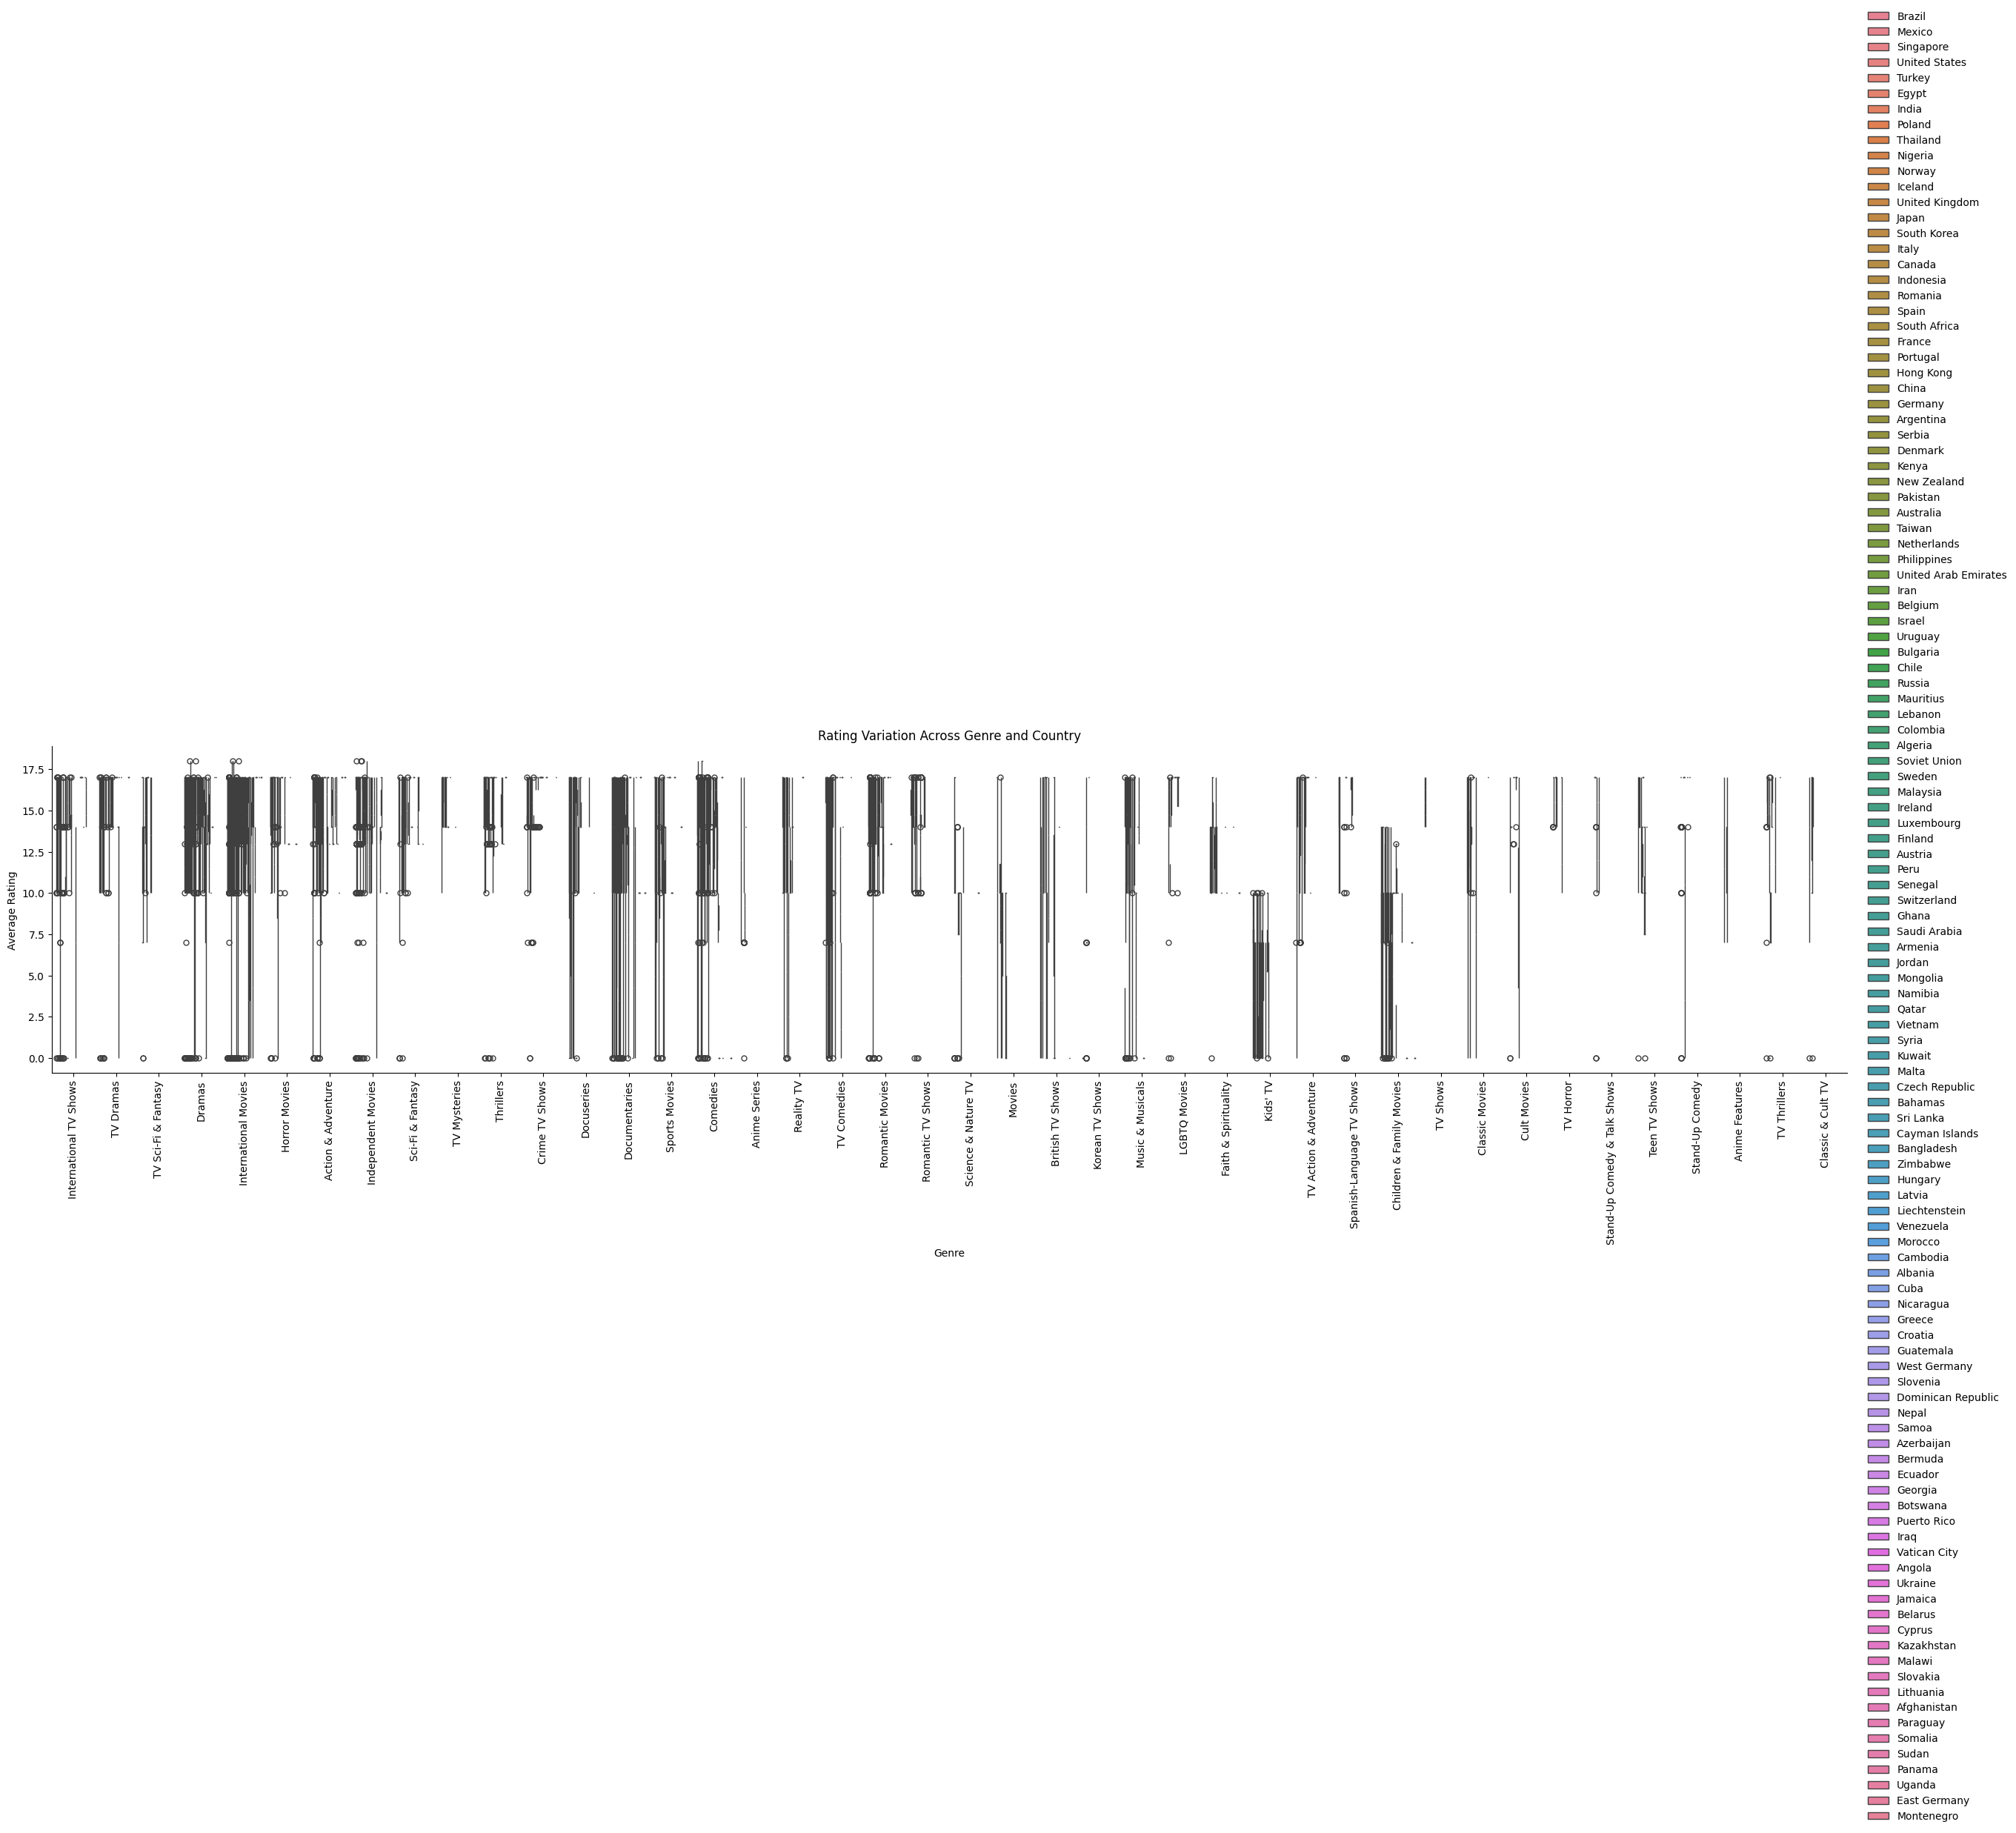

In [17]:
sns.catplot(
    x=genres_plot,
    y=rating_plot,
    hue=countries_plot,
    kind='box',
    height=5,
    aspect=5
)

plt.xticks(rotation=90)
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.title("Rating Variation Across Genre and Country")
plt.show()


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


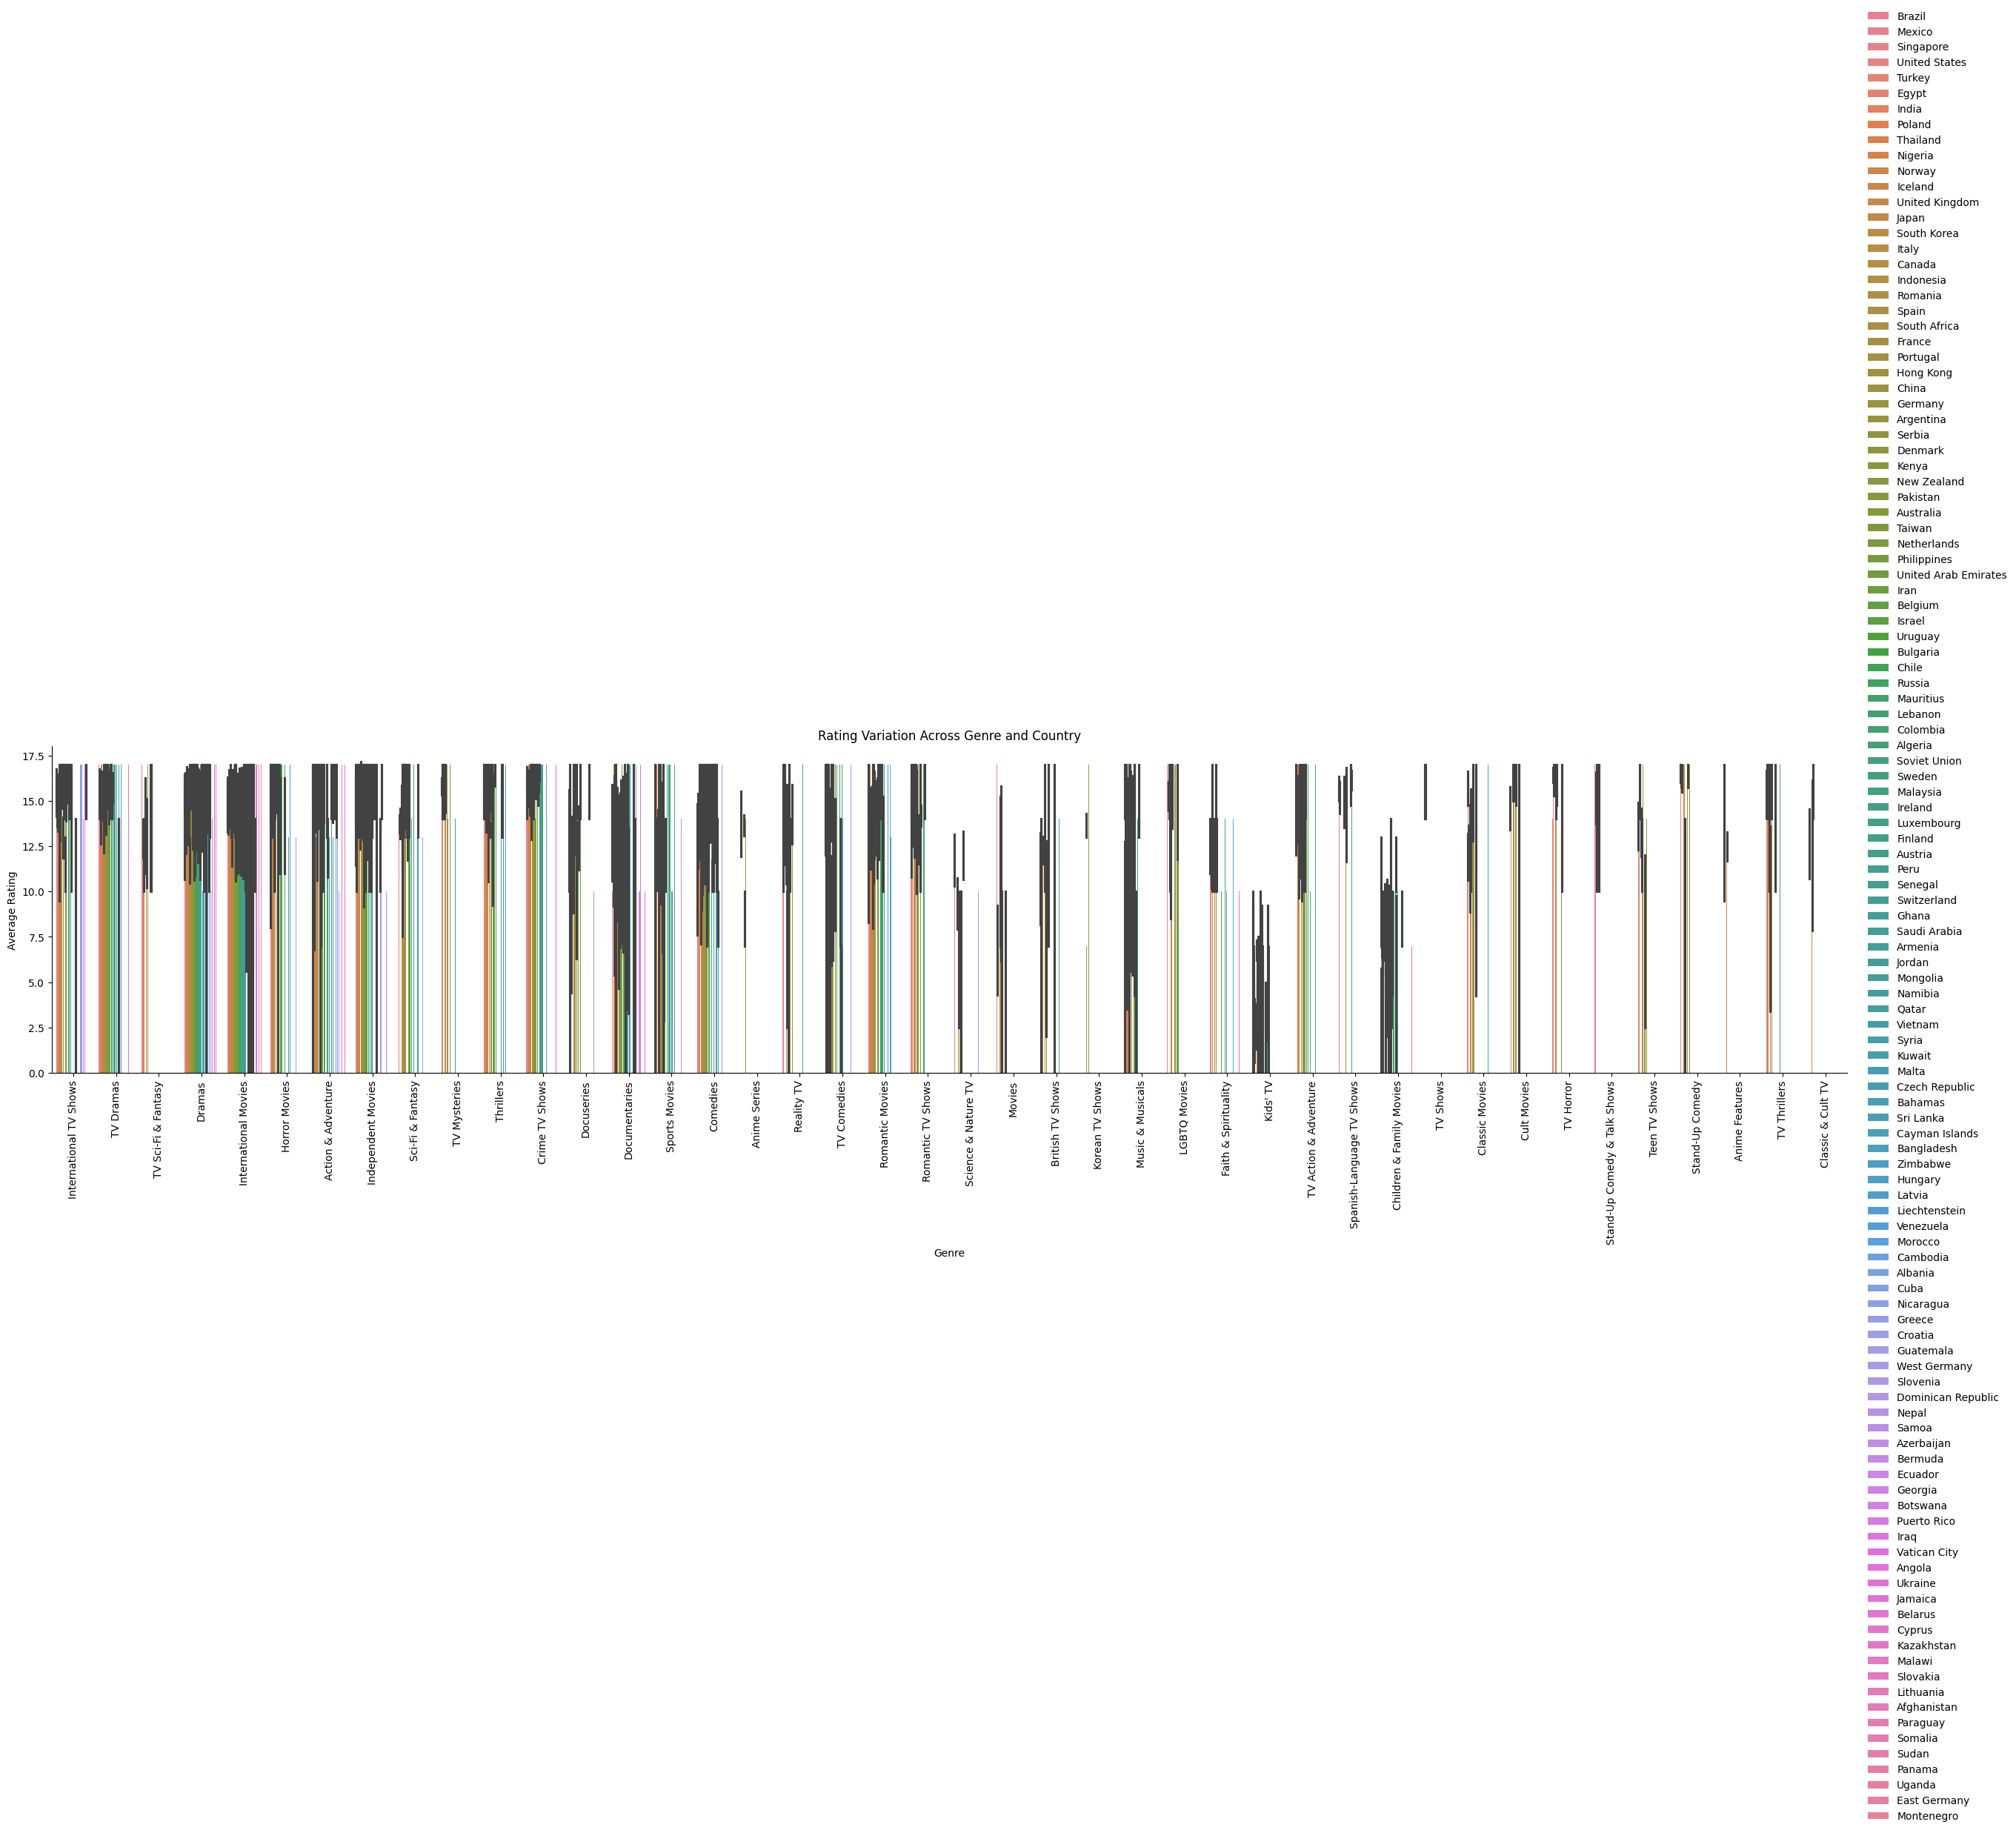

In [18]:
sns.catplot(
    x=genres_plot,
    y=rating_plot,
    hue=countries_plot,
    kind='bar',
    height=5,
    aspect=5
)

plt.xticks(rotation=90)
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.title("Rating Variation Across Genre and Country")
plt.show()


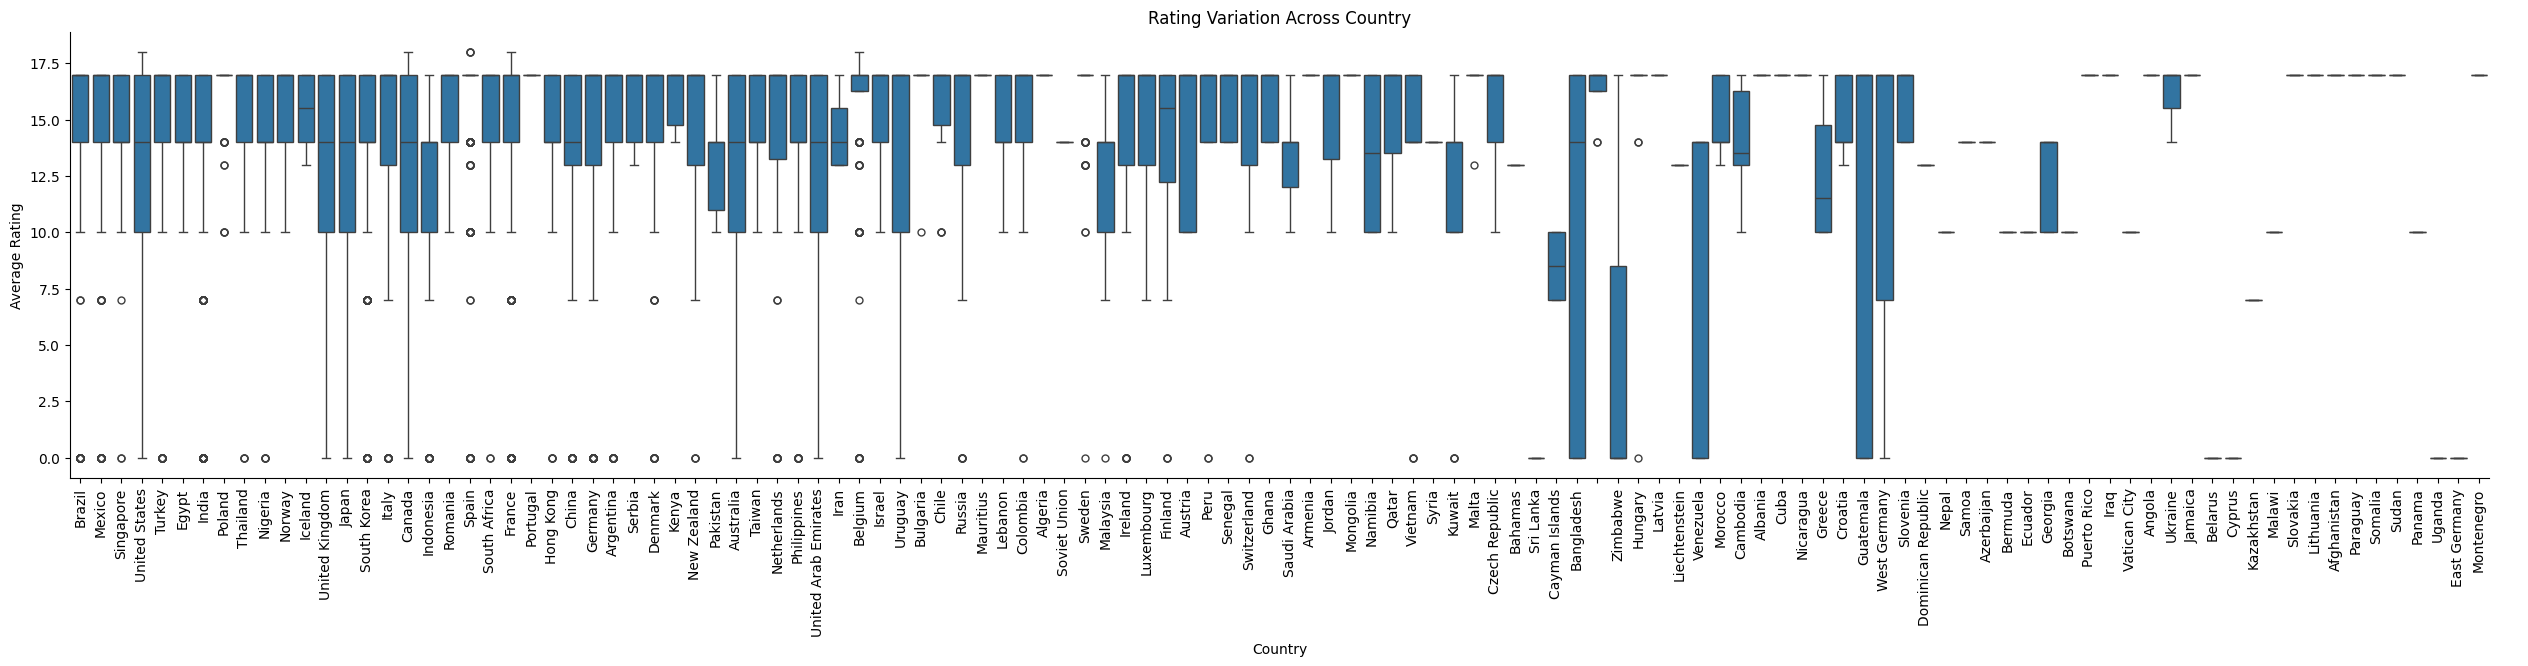

In [19]:
sns.catplot(x=countries_plot, y=rating_plot, kind="box", height=5, aspect=5)
plt.xticks(rotation=90)
plt.xlabel("Country")
plt.ylabel("Average Rating")
plt.title("Rating Variation Across Country")
plt.show()

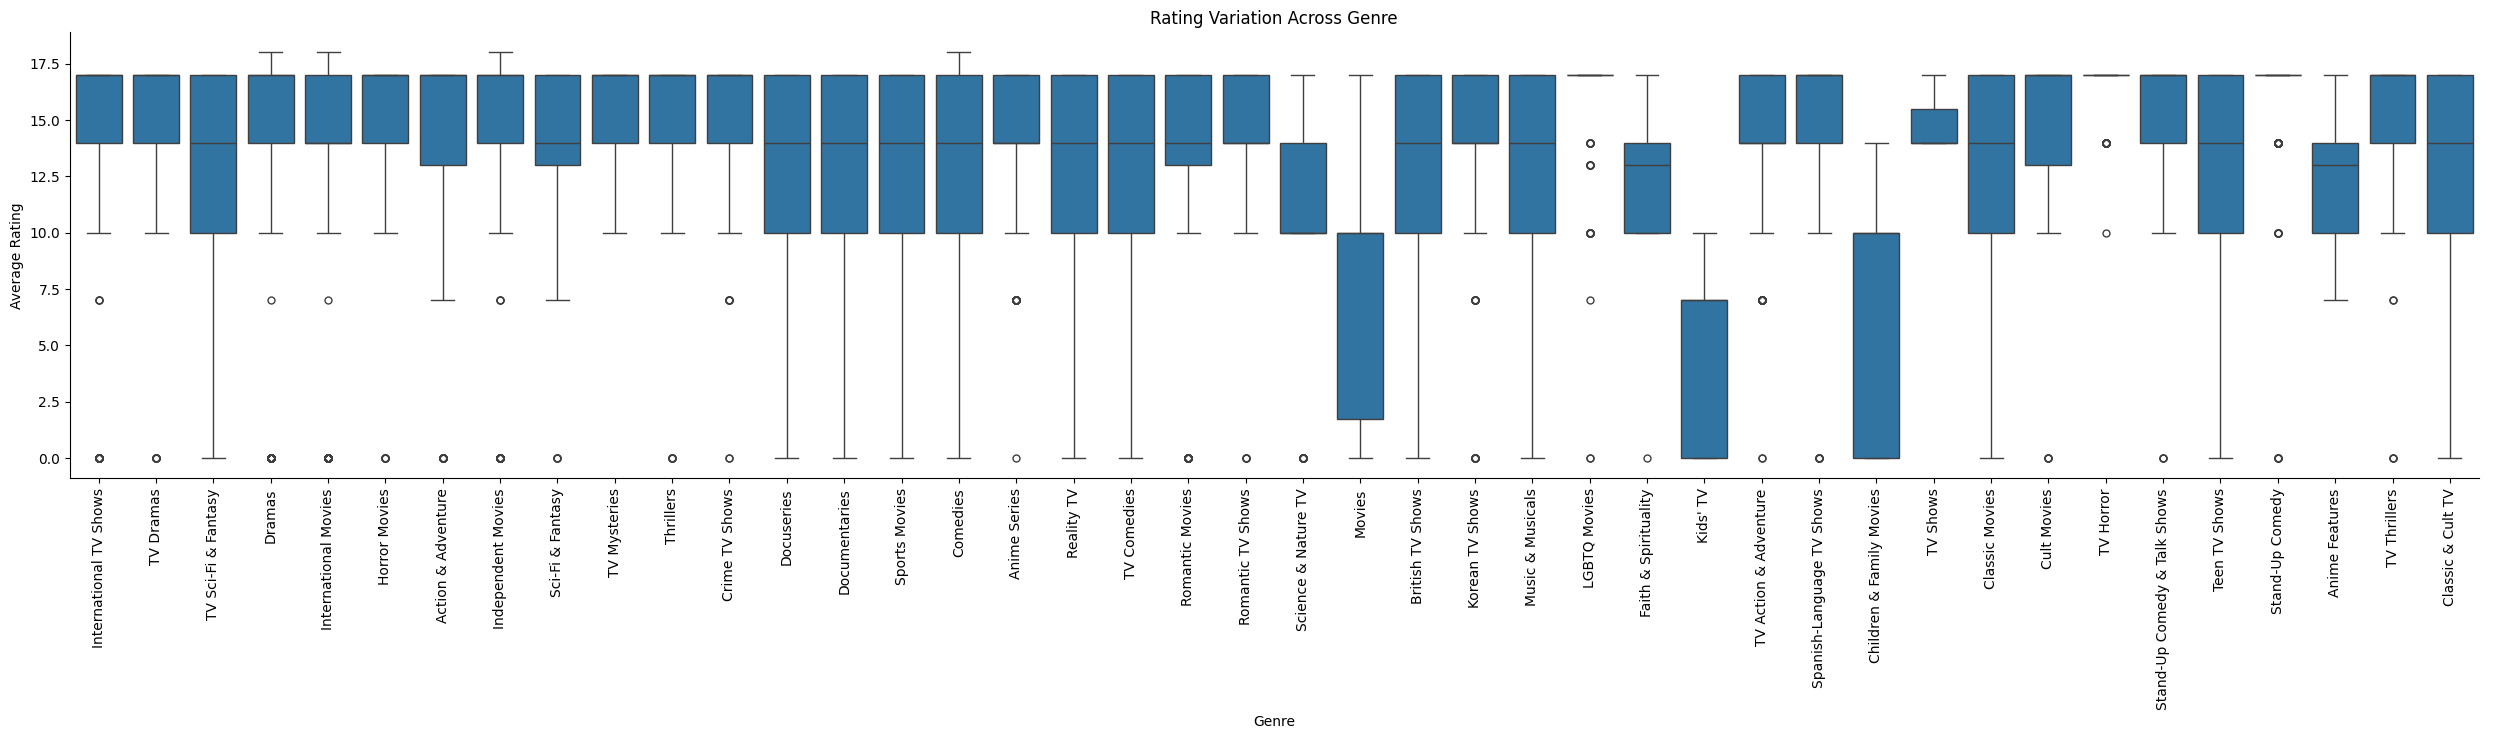

In [20]:
sns.catplot(x=genres_plot, y=rating_plot, kind="box", height=5, aspect=5)
plt.xticks(rotation=90)
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.title("Rating Variation Across Genre")
plt.show()